# 02. Inferencia conjunta de RetiScan

Este notebook implementa una prueba de inferencia conjunta utilizando
los modelos finales seleccionados para Retinopatía Diabética y Glaucoma.

A partir de una fotografía de fondo de ojo se ejecutan de manera
independiente:

- EfficientNetB3+SE para clasificación de Retinopatía Diabética.
- ResNet50V2 para clasificación de riesgo de Glaucoma.

Las salidas son posteriormente calibradas utilizando los calibradores
ajustados exclusivamente sobre Validation.

Este notebook no entrena ni modifica los modelos.

## 1. Importación de dependencias y definición de rutas

Se importan las bibliotecas de manipulación numérica, carga de modelos en Keras y manejo de imágenes, configurando las rutas hacia los modelos definitivos y sus calibradores de confianza.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)

RD_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "RD"
    / "efficientnetb3_se"
    / "efficientnetb3_se_finetune_best.keras"
)
GLAUCOMA_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "glaucoma"
    / "resnet50v2"
    / "resnet50v2_finetune_best.keras"
)
RD_CALIBRATION_PATH = (
    PROJECT_ROOT
    / "results"
    / "calibration"
    / "rd_temperature_scaling.json"
)
GLAUCOMA_CALIBRATION_PATH = (
    PROJECT_ROOT
    / "results"
    / "calibration"
    / "glaucoma_platt_scaling.json"
)

print(
    "Modelo RD:",
    RD_MODEL_PATH.exists()
)
print(
    "Modelo Glaucoma:",
    GLAUCOMA_MODEL_PATH.exists()
)
print(
    "Calibrador RD:",
    RD_CALIBRATION_PATH.exists()
)
print(
    "Calibrador Glaucoma:",
    GLAUCOMA_CALIBRATION_PATH.exists()
)

I0000 00:00:1790774799.169678  332158 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790774799.815293  332158 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790774802.149460  332158 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Modelo RD: True
Modelo Glaucoma: True
Calibrador RD: True
Calibrador Glaucoma: True


## 2. Carga de modelos definitivos y parámetros de calibración

Se instancian en memoria los modelos entrenados y congelados sin compilar, y se recuperan los parámetros de Temperature Scaling (RD) y Platt Scaling con su umbral calibrado (Glaucoma).

In [2]:
rd_model = tf.keras.models.load_model(
    RD_MODEL_PATH,
    compile=False
)
glaucoma_model = tf.keras.models.load_model(
    GLAUCOMA_MODEL_PATH,
    compile=False
)

with open(
    RD_CALIBRATION_PATH,
    "r",
    encoding="utf-8"
) as f:
    rd_calibration = json.load(f)

with open(
    GLAUCOMA_CALIBRATION_PATH,
    "r",
    encoding="utf-8"
) as f:
    glaucoma_calibration = json.load(f)

RD_TEMPERATURE = float(
    rd_calibration["temperature"]
)
GLAUCOMA_A = float(
    glaucoma_calibration.get("A", glaucoma_calibration.get("a"))
)
GLAUCOMA_B = float(
    glaucoma_calibration.get("B", glaucoma_calibration.get("b"))
)
GLAUCOMA_RAW_THRESHOLD = float(
    glaucoma_calibration[
        "raw_threshold"
    ]
)
GLAUCOMA_CALIBRATED_THRESHOLD = float(
    glaucoma_calibration[
        "calibrated_threshold"
    ]
)

print(
    "RD Temperature:",
    RD_TEMPERATURE
)
print(
    "Glaucoma A:",
    GLAUCOMA_A
)
print(
    "Glaucoma B:",
    GLAUCOMA_B
)
print(
    "Umbral glaucoma bruto:",
    GLAUCOMA_RAW_THRESHOLD
)
print(
    "Umbral glaucoma calibrado:",
    GLAUCOMA_CALIBRATED_THRESHOLD
)

W0000 00:00:1790774805.066850  332158 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1790774805.073304  332158 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790774805.331281  332158 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


RD Temperature: 1.1019132499924953
Glaucoma A: 0.7882374024841463
Glaucoma B: -0.5499764599494648
Umbral glaucoma bruto: 0.100155
Umbral glaucoma calibrado: 0.0927462872218843


## 3. Mapeo de categorías clínicas del sistema RetiScan

Se definen los diccionarios canónicos de etiquetas diagnósticas para la emisión estructurada de los resultados clínicos de ambas patologías.

In [3]:
RD_LABELS = {
    0: "Sin indicios de Retinopatía Diabética",
    1: "Leve",
    2: "Moderada",
    3: "Severa",
    4: "Proliferativa"
}

GLAUCOMA_LABELS = {
    0: "Bajo riesgo de Glaucoma",
    1: "Alto riesgo de Glaucoma"
}

## 4. Carga de la política de revisión por baja confianza

Se cargan los umbrales de baja confianza congelados en `results/calibration/review_policy.json` (0.83 para Retinopatía Diabética y 0.29 para Glaucoma) para activar de forma desacoplada la advertencia `Requiere revisión`.

In [4]:
REVIEW_POLICY_PATH = (
    PROJECT_ROOT
    / "results"
    / "calibration"
    / "review_policy.json"
)

with open(
    REVIEW_POLICY_PATH,
    "r",
    encoding="utf-8"
) as f:
    review_policy = json.load(f)

RD_REVIEW_THRESHOLD = float(
    review_policy[
        "diabetic_retinopathy"
    ][
        "review_threshold"
    ]
)
GLAUCOMA_REVIEW_THRESHOLD = float(
    review_policy[
        "glaucoma"
    ][
        "review_threshold"
    ]
)

print(
    "Umbral revisión RD:",
    RD_REVIEW_THRESHOLD
)
print(
    "Umbral revisión Glaucoma:",
    GLAUCOMA_REVIEW_THRESHOLD
)

Umbral revisión RD: 0.8300000000000001
Umbral revisión Glaucoma: 0.29


## 5. Preprocesamiento para inferencia

La fotografía original se somete primero al mismo preprocesamiento
geométrico utilizado durante los experimentos.

El procedimiento:

1. detecta el campo retinal;
2. obtiene la región principal;
3. construye su envolvente convexa;
4. incorpora un margen del 2 %;
5. recorta la región retinal;
6. agrega padding negro cuadrado;
7. redimensiona a 384 × 384 píxeles.

Posteriormente, cada modelo recibe la representación numérica utilizada
durante su entrenamiento.

- EfficientNetB3+SE recibe la imagen RGB `float32` en rango [0,255].
- ResNet50V2 recibe adicionalmente el `preprocess_input` específico
  de ResNetV2, generando valores aproximadamente en [-1,1].

### 5.1. Preprocesamiento geométrico común

Rutina de segmentación de campo retinal (FOV) mediante detección de intensidad, cierre morfológico, envolvente convexa con margen de seguridad del 2 %, adición de padding cuadrado simétrico y redimensionamiento sin deformación a 384 × 384 píxeles.

In [5]:
import cv2

IMAGE_SIZE = 384

def preprocess_retinal_fov(
    image_path,
    output_size=384,
    threshold=10,
    margin_ratio=0.02,
    morph_kernel_size=15
):
    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )
    if image_bgr is None:
        raise ValueError(
            f"No se pudo leer la imagen: {image_path}"
        )
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )
    gray = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2GRAY
    )
    binary_mask = (
        gray > threshold
    ).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            morph_kernel_size,
            morph_kernel_size
        )
    )
    morph_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            morph_mask,
            connectivity=8
        )
    )
    h_img, w_img = image_rgb.shape[:2]
    if num_labels <= 1:
        mask = morph_mask
        x, y, w, h = 0, 0, w_img, h_img
    else:
        areas = stats[
            1:,
            cv2.CC_STAT_AREA
        ]
        largest_component = (
            1 + np.argmax(areas)
        )
        component_mask = (
            labels == largest_component
        ).astype(np.uint8) * 255

        contours, _ = cv2.findContours(
            component_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        if len(contours) == 0:
            mask = component_mask
            x, y, w, h = 0, 0, w_img, h_img
        else:
            largest_contour = max(
                contours,
                key=cv2.contourArea
            )
            hull = cv2.convexHull(
                largest_contour
            )
            mask = np.zeros_like(
                component_mask
            )
            cv2.fillConvexPoly(
                mask,
                hull,
                255
            )
            x, y, w, h = cv2.boundingRect(
                hull
            )

    margin_x = int(w * margin_ratio)
    margin_y = int(h * margin_ratio)
    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(w_img, x + w + margin_x)
    y2 = min(h_img, y + h + margin_y)

    masked_rgb = cv2.bitwise_and(
        image_rgb,
        image_rgb,
        mask=mask
    )
    crop = masked_rgb[
        y1:y2,
        x1:x2
    ]

    crop_h, crop_w = crop.shape[:2]
    max_dim = max(crop_h, crop_w)
    padded = np.zeros(
        (max_dim, max_dim, 3),
        dtype=crop.dtype
    )
    y_offset = (max_dim - crop_h) // 2
    x_offset = (max_dim - crop_w) // 2
    padded[
        y_offset:y_offset + crop_h,
        x_offset:x_offset + crop_w
    ] = crop

    processed = cv2.resize(
        padded,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA
    )

    return image_rgb, processed

## 6. Preparar entrada para cada modelo

Adaptación numérica específica requerida por cada red neuronal entrenada:
- **EfficientNetB3+SE (RD)**: Tensor tridimensional `float32` conservando el rango `[0, 255]`.
- **ResNet50V2 (Glaucoma)**: Tensor `float32` transformado mediante `tf.keras.applications.resnet_v2.preprocess_input` en el rango `[-1, 1]`.

In [6]:
def prepare_rd_input(
    processed_rgb
):
    image = processed_rgb.astype(
        np.float32
    )
    image = np.expand_dims(
        image,
        axis=0
    )
    return image


def prepare_glaucoma_input(
    processed_rgb
):
    image = processed_rgb.astype(
        np.float32
    )
    image = (
        tf.keras.applications
        .resnet_v2
        .preprocess_input(
            image
        )
    )
    image = np.expand_dims(
        image,
        axis=0
    )
    return image

## 7. Funciones de calibración

Implementación de los calibradores previamente ajustados y congelados sobre el conjunto Validation:
- Temperature Scaling para los scores de 5 clases de Retinopatía Diabética.
- Platt Scaling mediante regresión logística monótona para el score univariado de Glaucoma.

In [7]:
def calibrate_rd_scores(
    raw_scores,
    temperature
):
    eps = 1e-7
    raw_scores = np.clip(
        raw_scores,
        eps,
        1.0
    )
    logits = np.log(
        raw_scores
    )
    logits = (
        logits
        / temperature
    )
    logits = (
        logits
        - np.max(logits)
    )
    exp_logits = np.exp(
        logits
    )
    calibrated = (
        exp_logits
        / exp_logits.sum()
    )
    return calibrated


def calibrate_glaucoma_score(
    raw_score,
    a,
    b
):
    eps = 1e-7
    raw_score = np.clip(
        raw_score,
        eps,
        1.0 - eps
    )
    raw_logit = np.log(
        raw_score
        /
        (1.0 - raw_score)
    )
    calibrated_probability = (
        1.0
        /
        (
            1.0
            + np.exp(
                -(
                    a * raw_logit
                    + b
                )
            )
        )
    )
    return float(
        calibrated_probability
    )

## 8. Función de inferencia para Retinopatía Diabética

Generación de predicciones de 5 grados de severidad con EfficientNetB3+SE, aplicación de Temperature Scaling (\(T = 1.101913\)), y extracción de la clase predicha con su respectiva confianza calibrada y verificación de la política de revisión (\(confianza < 0.83\)).

In [8]:
def predict_rd(
    processed_rgb
):
    model_input = prepare_rd_input(
        processed_rgb
    )
    raw_scores = rd_model.predict(
        model_input,
        verbose=0
    )[0]
    calibrated_scores = (
        calibrate_rd_scores(
            raw_scores,
            RD_TEMPERATURE
        )
    )
    predicted_class = int(
        np.argmax(
            calibrated_scores
        )
    )
    confidence = float(
        calibrated_scores[
            predicted_class
        ]
    )
    requires_review = bool(
        confidence < RD_REVIEW_THRESHOLD
    )
    return {
        "class_id":
            predicted_class,
        "label":
            RD_LABELS[
                predicted_class
            ],
        "confidence":
            confidence,
        "requires_review":
            requires_review,
        "review_threshold":
            RD_REVIEW_THRESHOLD,
        "raw_scores":
            raw_scores,
        "calibrated_scores":
            calibrated_scores
    }

## 9. Función de inferencia para Glaucoma

Inferencia binaria mediante ResNet50V2 aplicando el umbral bruto congelado (\(0.100155\)). Se calcula la probabilidad calibrada de alto riesgo con Platt Scaling y se computa el índice normalizado de confianza de decisión, evaluando si el caso requiere revisión (\(confianza < 0.29\)).

In [9]:
def predict_glaucoma(
    processed_rgb
):
    model_input = (
        prepare_glaucoma_input(
            processed_rgb
        )
    )
    raw_score = float(
        glaucoma_model.predict(
            model_input,
            verbose=0
        )[0][0]
    )
    predicted_class = int(
        raw_score
        >= GLAUCOMA_RAW_THRESHOLD
    )
    calibrated_probability = (
        calibrate_glaucoma_score(
            raw_score,
            GLAUCOMA_A,
            GLAUCOMA_B
        )
    )
    if (
        calibrated_probability
        >= GLAUCOMA_CALIBRATED_THRESHOLD
    ):
        decision_confidence = (
            calibrated_probability
            - GLAUCOMA_CALIBRATED_THRESHOLD
        ) / (
            1.0
            - GLAUCOMA_CALIBRATED_THRESHOLD
        )
    else:
        decision_confidence = (
            GLAUCOMA_CALIBRATED_THRESHOLD
            - calibrated_probability
        ) / (
            GLAUCOMA_CALIBRATED_THRESHOLD
        )
    decision_confidence = float(
        np.clip(
            decision_confidence,
            0.0,
            1.0
        )
    )
    requires_review = bool(
        decision_confidence
        < GLAUCOMA_REVIEW_THRESHOLD
    )
    return {
        "class_id":
            predicted_class,
        "label":
            GLAUCOMA_LABELS[
                predicted_class
            ],
        "confidence":
            decision_confidence,
        "requires_review":
            requires_review,
        "review_threshold":
            GLAUCOMA_REVIEW_THRESHOLD,
        "raw_score":
            raw_score,
        "calibrated_high_risk_probability":
            calibrated_probability
    }

## 10. Función conjunta de RetiScan

Integración del pipeline desacoplado que separa nítidamente los resultados de soporte clínico de RD y Glaucoma de la advertencia asistencial de baja confianza.

In [10]:
def predict_retiscan(
    image_path
):
    (
        original_rgb,
        processed_rgb
    ) = preprocess_retinal_fov(
        image_path,
        output_size=IMAGE_SIZE
    )
    rd_result = predict_rd(
        processed_rgb
    )
    glaucoma_result = (
        predict_glaucoma(
            processed_rgb
        )
    )

    any_review_required = (
        rd_result["requires_review"]
        or glaucoma_result[
            "requires_review"
        ]
    )
    no_pathology_indications = (
        rd_result["class_id"] == 0
        and
        glaucoma_result["class_id"] == 0
    )

    if (
    no_pathology_indications
    and not any_review_required
    ):
        summary = (
            "Sin indicios de las "
            "patologías evaluadas."
    )
    else:
        summary = None


    if any_review_required:
        review_message = (
            "Requiere revisión por baja "
            "confianza del modelo."
        )
    else:
        review_message = None

    return {
        "image_path":
            str(image_path),
        "original":
            original_rgb,
        "processed":
            processed_rgb,
        "summary":
            summary,
        "requires_review":
            any_review_required,
        "review_message":
            review_message,
        "diabetic_retinopathy":
            rd_result,
        "glaucoma":
            glaucoma_result
    }

## 11. Verificación de dimensiones de entrada y salida de los modelos

Comprobación estricta de las dimensiones de entrada y tensores de salida de cada modelo antes de someter imágenes reales a la función de inferencia conjunta.

In [11]:
print(
    "RD input shape:",
    rd_model.input_shape
)
print(
    "RD output shape:",
    rd_model.output_shape
)
print(
    "Glaucoma input shape:",
    glaucoma_model.input_shape
)
print(
    "Glaucoma output shape:",
    glaucoma_model.output_shape
)

RD input shape: (None, 384, 384, 3)
RD output shape: (None, 5)
Glaucoma input shape: (None, 384, 384, 3)
Glaucoma output shape: (None, 1)


## 12. Selección de una retinografía conocida

Se selecciona una retinografía del conjunto de datos para validar de forma integral la ejecución secuencial de los pipelines de preprocesamiento, inferencia y calibración post-hoc.

In [12]:
TEST_IMAGE_PATH = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
    / "raw"
    / "train_images"
    / "0024cdab0c1e.png"
)

print(
    "Imagen existe:",
    TEST_IMAGE_PATH.exists()
)
print(
    "Ruta:",
    TEST_IMAGE_PATH
)

Imagen existe: True
Ruta: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/raw/train_images/0024cdab0c1e.png


## 13. Ejecución de la inferencia conjunta y visualización

Se invoca la función `predict_retiscan` sobre la fotografía retinal y se genera una comparativa visual entre la retinografía original y la versión cuadrada recortada a 384 × 384 píxeles suministrada a las redes neuronales.

I0000 00:00:1790774814.070411  332480 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790774816.061901  332480 service.cc:153] XLA service 0x726f42eb78f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790774816.061937  332480 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790774816.111820  332480 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790774820.497272  332480 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


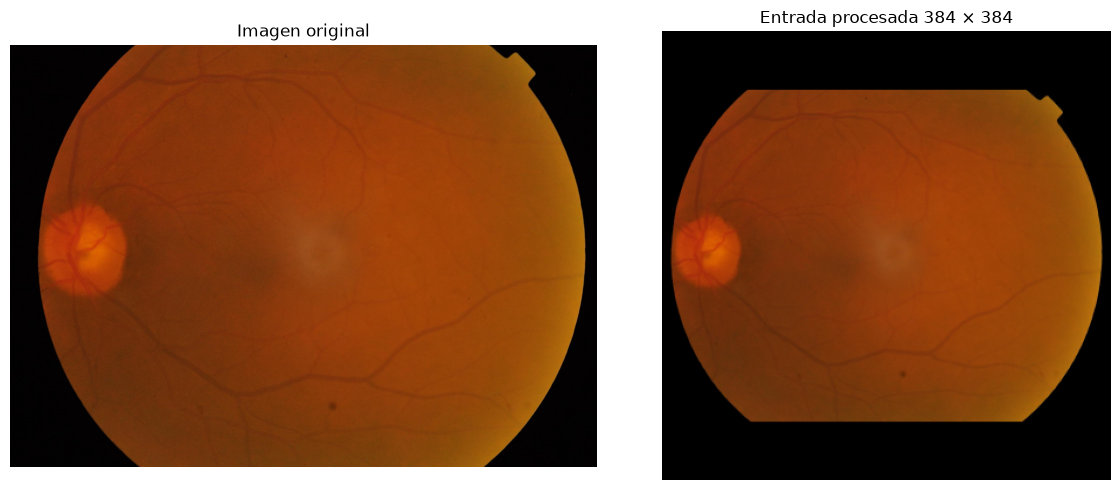

In [13]:
import matplotlib.pyplot as plt

result = predict_retiscan(
    TEST_IMAGE_PATH
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)
axes[0].imshow(
    result["original"]
)
axes[0].set_title(
    "Imagen original"
)
axes[0].axis("off")

axes[1].imshow(
    result["processed"]
)
axes[1].set_title(
    "Entrada procesada 384 × 384"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 14. Detalle del resultado de soporte clínico para Retinopatía Diabética

Desglose de la inferencia generada por EfficientNetB3+SE, incluyendo la categoría ordinal predicha, la etiqueta cualitativa, la confianza calibrada mediante Temperature Scaling y el vector completo de probabilidades por clase.

In [14]:
rd_result = result[
    "diabetic_retinopathy"
]

print(
    "========== RETINOPATÍA DIABÉTICA =========="
)
print(
    "Clase:",
    rd_result["class_id"]
)
print(
    "Resultado:",
    rd_result["label"]
)
print(
    "Confianza calibrada:",
    f"{rd_result['confidence'] * 100:.2f}%"
)
print(
    "\nScores calibrados:"
)
for class_id, score in enumerate(
    rd_result["calibrated_scores"]
):
    print(
        f"{class_id} - "
        f"{RD_LABELS[class_id]}: "
        f"{score * 100:.2f}%"
    )

========== RETINOPATÍA DIABÉTICA ==========
Clase: 1
Resultado: Leve
Confianza calibrada: 89.49%

Scores calibrados:
0 - Sin indicios de Retinopatía Diabética: 1.02%
1 - Leve: 89.49%
2 - Moderada: 7.24%
3 - Severa: 0.32%
4 - Proliferativa: 1.93%


## 15. Detalle del resultado de soporte clínico para Glaucoma

Evaluación de riesgo emitida por ResNet50V2. Se reporta el score sigmoideo bruto evaluado frente al umbral operativo congelado (\(0.100155\)) y la probabilidad calibrada de alto riesgo estimada por Platt Scaling frente a su umbral equivalente (\(9.27\%\)).

In [15]:
glaucoma_result = result[
    "glaucoma"
]

print(
    "=============== GLAUCOMA ==============="
)

print(
    "Resultado:",
    glaucoma_result["label"]
)

print(
    "Nivel de confianza:",
    f"{glaucoma_result['confidence'] * 100:.2f}%"
)

print(
    "Requiere revisión:",
    "Sí"
    if glaucoma_result["requires_review"]
    else "No"
)

print(
    "\n--- Información técnica ---"
)

print(
    "Score bruto:",
    f"{glaucoma_result['raw_score']:.6f}"
)

print(
    "Umbral operativo:",
    f"{GLAUCOMA_RAW_THRESHOLD:.6f}"
)

print(
    "Probabilidad calibrada de Alto riesgo:",
    f"{glaucoma_result['calibrated_high_risk_probability'] * 100:.2f}%"
)

print(
    "Umbral equivalente calibrado:",
    f"{GLAUCOMA_CALIBRATED_THRESHOLD * 100:.2f}%"
)

print(
    "Umbral de revisión:",
    f"{GLAUCOMA_REVIEW_THRESHOLD * 100:.2f}%"
)

=============== GLAUCOMA ===============
Resultado: Bajo riesgo de Glaucoma
Nivel de confianza: 84.64%
Requiere revisión: No

--- Información técnica ---
Score bruto: 0.009216
Umbral operativo: 0.100155
Probabilidad calibrada de Alto riesgo: 1.42%
Umbral equivalente calibrado: 9.27%
Umbral de revisión: 29.00%


## 16. Consolidación del informe de soporte clínico RetiScan

Estructuración del reporte final que desacopla la categorización clínica individual del resumen global y de la advertencia asistencial de baja confianza.

In [16]:
rd_result = result[
    "diabetic_retinopathy"
]

glaucoma_result = result[
    "glaucoma"
]


print(
    "\n"
    "========================================="
)

print(
    "           RESULTADO RETISCAN"
)

print(
    "========================================="
)


# =========================
# RETINOPATÍA DIABÉTICA
# =========================

print(
    "\nRETINOPATÍA DIABÉTICA"
)

print(
    f"Resultado: "
    f"{rd_result['label']}"
)

print(
    f"Nivel de confianza: "
    f"{rd_result['confidence'] * 100:.2f}%"
)

if rd_result[
    "requires_review"
]:
    print(
        "Advertencia: "
        "Requiere revisión por "
        "baja confianza."
    )


# =========================
# GLAUCOMA
# =========================

print(
    "\nGLAUCOMA"
)

print(
    f"Resultado: "
    f"{glaucoma_result['label']}"
)

print(
    f"Nivel de confianza: "
    f"{glaucoma_result['confidence'] * 100:.2f}%"
)

if glaucoma_result[
    "requires_review"
]:
    print(
        "Advertencia: "
        "Requiere revisión por "
        "baja confianza."
    )


# =========================
# RESUMEN
# =========================

if result[
    "summary"
] is not None:

    print(
        "\nRESUMEN"
    )

    print(
        result["summary"]
    )


# =========================
# ADVERTENCIA GENERAL
# =========================

if result[
    "review_message"
] is not None:

    print(
        "\nADVERTENCIA GENERAL"
    )

    print(
        result["review_message"]
    )


           RESULTADO RETISCAN

RETINOPATÍA DIABÉTICA
Resultado: Leve
Nivel de confianza: 89.49%

GLAUCOMA
Resultado: Bajo riesgo de Glaucoma
Nivel de confianza: 84.64%
